Training LSTM Model...
Epoch 1/20


/home/arsh/Desktop/Sem 6/IR/assignments/irenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0061 - val_loss: 5.5087e-04
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0023 - val_loss: 4.6733e-04
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020 - val_loss: 6.2279e-04
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0019 - val_loss: 4.7944e-04
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0017 - val_loss: 6.9660e-04
Epoch 7/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 8.0155e-04
Epoch 9/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 7.4157e-04
Epoch 10/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 11/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014 - val_loss: 6.1983e-04
Epoch 12/20
114/114 

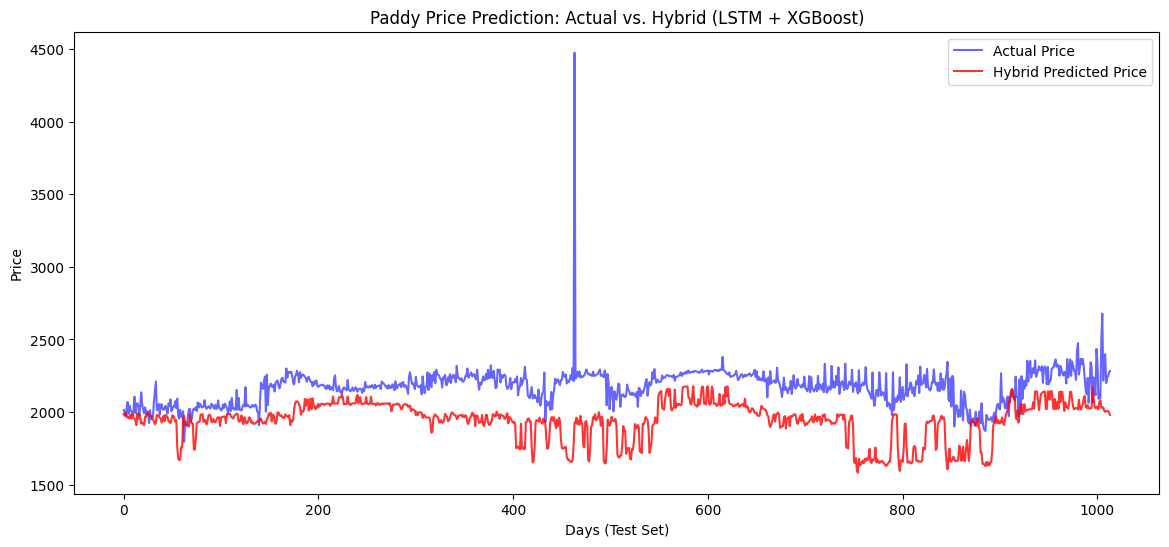

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# ==========================================
# 1. Load and Prepare Data
# ==========================================
df = pd.read_csv('../../final_combined_dataset.csv')

# Ensure chronological order (critical for Time Series)
df['Calendar'] = pd.to_datetime(df['Calendar'])
df = df.sort_values('Calendar').reset_index(drop=True)

# Select features (Exclude text/date columns)
target_col = 'Mandi Modal Price (AgMarknet)'
# Add all your relevant numerical columns here based on your correlation plot
feature_cols = [
    'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 
    'Yield', 'MSP_Fixed', 'WPI_Paddy', 'Crude_Price_USD'
] 

# Handle any missing values by forward-filling
df[feature_cols + [target_col]] = df[feature_cols + [target_col]].ffill()

# Scale the data (LSTM requires features to be scaled between 0 and 1)
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(df[feature_cols])
scaled_target = target_scaler.fit_transform(df[[target_col]])

# ==========================================
# 2. Create Time-Series Sequences
# ==========================================
def create_sequences(features, target, seq_length):
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i:(i + seq_length)])
        y.append(target[i + seq_length])
    return np.array(X), np.array(y)

sequence_length = 7 # Look back 7 days to predict the next day
X, y = create_sequences(scaled_features, scaled_target, sequence_length)

# Chronological Train-Test Split (80% train, 20% test)
split_idx = int(len(X) * 0.8)
X_train_lstm, X_test_lstm = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# ==========================================
# 3. Train the LSTM Model
# ==========================================
print("Training LSTM Model...")
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, len(feature_cols)), return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# Generate LSTM predictions to use as features for XGBoost
lstm_train_preds = lstm_model.predict(X_train_lstm)
lstm_test_preds = lstm_model.predict(X_test_lstm)

# ==========================================
# 4. Prepare Data for XGBoost & Train
# ==========================================
print("Training XGBoost Hybrid Model...")
# For XGBoost, we only need the tabular data of the "current" day (the last day of our sequence)
X_train_tabular = X_train_lstm[:, -1, :] 
X_test_tabular = X_test_lstm[:, -1, :]

# Stack the LSTM predictions alongside the tabular features
X_train_hybrid = np.hstack((X_train_tabular, lstm_train_preds))
X_test_hybrid = np.hstack((X_test_tabular, lstm_test_preds))

# Train XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_hybrid, y_train.ravel())

# Final Hybrid Predictions
hybrid_predictions_scaled = xgb_model.predict(X_test_hybrid)

# Inverse transform to get actual price values
hybrid_predictions = target_scaler.inverse_transform(hybrid_predictions_scaled.reshape(-1, 1))
actual_prices = target_scaler.inverse_transform(y_test)

# ==========================================
# 5. Evaluate and Visualize
# ==========================================
rmse = np.sqrt(mean_squared_error(actual_prices, hybrid_predictions))
mae = mean_absolute_error(actual_prices, hybrid_predictions)
r2 = r2_score(actual_prices, hybrid_predictions)
mape = mean_absolute_percentage_error(actual_prices, hybrid_predictions) * 100

print("\n--- Hybrid Model Performance ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2 Score: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

# Plotting the results
plt.figure(figsize=(14, 6))
plt.plot(actual_prices, label='Actual Price', color='blue', alpha=0.6)
plt.plot(hybrid_predictions, label='Hybrid Predicted Price', color='red', alpha=0.8)
plt.title('Paddy Price Prediction: Actual vs. Hybrid (LSTM + XGBoost)')
plt.xlabel('Days (Test Set)')
plt.ylabel('Price')
plt.legend()
plt.show()